In [3]:
import numpy as np
import pandas as pd

In [ ]:
# Write the three annualisation formulas.
annual_log_return = daily_mean * 365
annual_simple_return = np.exp(annual_log_return) - 1
annual_vol = std * np.sqrt(365)

sharpe = (annual_log_return - risk_free)/ annual_vol

In [5]:
import yfinance as yf

btc = yf.download("BTC-USD", start="2020-01-01", end="2025-12-31")
btc.columns = btc.columns.droplevel(1)  
print(btc.head())     # first 5 rows
print(btc.tail())     # last 5 rows
print(btc.shape)      # (rows, columns)
print(btc.info())     # column types, missing values
print(btc.describe()) # mean, std, min, max, quartiles

/var/folders/x7/_9kdc2hd3g3d62j28dsz3nx40000gn/T/ipykernel_5717/1279041349.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2020-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open       Volume
Date                                                                       
2020-01-01  7200.174316  7254.330566  7174.944336  7194.892090  18565664997
2020-01-02  6985.470215  7212.155273  6935.270020  7202.551270  20802083465
2020-01-03  7344.884277  7413.715332  6914.996094  6984.428711  28111481032
2020-01-04  7410.656738  7427.385742  7309.514160  7345.375488  18444271275
2020-01-05  7411.317383  7544.497070  7400.535645  7410.451660  19725074095
Price              Close          High           Low          Open  \
Date                                                                 
2025-12-26  87301.429688  89459.429688  86628.140625  87235.507812   
2025-12-27  87802.156250  87874.781250  87182.976562  87301.429688   
2025-12-28  87835.835938  87986.890625  87394.953125  87799.343750   
2025-12-29  87138.140625  90299.156250  86717.914062  87835.789062   
2025-12-30  88430.132812  89297.937500  86735.54

In [17]:
btc["log_returns"] = np.log(btc["Close"]/ btc["Close"].shift(1))
btc["rolling_vol_30"] = btc["log_returns"].rolling(window=30).std()

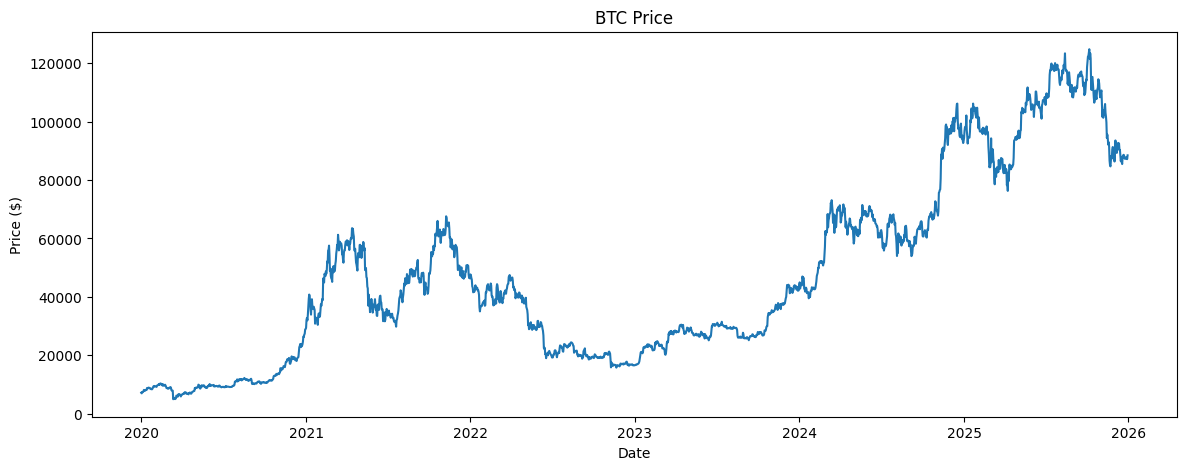

In [9]:
import matplotlib.pyplot as plt

# Simplest plot — BTC closing prices
plt.figure(figsize=(14, 5))
plt.plot(btc["Close"])
plt.title("BTC Price")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.show()

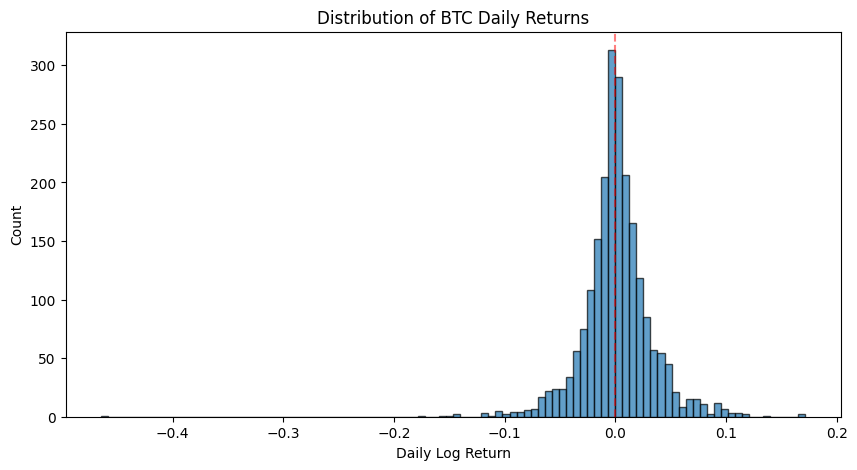

In [10]:
# Histogram — distribution of daily returns
plt.figure(figsize=(10, 5))
plt.hist(btc["log_returns"].dropna(), bins=100, edgecolor="black", alpha=0.7)
plt.axvline(x=0, color="red", linestyle="--", alpha=0.5)
plt.title("Distribution of BTC Daily Returns")
plt.xlabel("Daily Log Return")
plt.ylabel("Count")
plt.show()

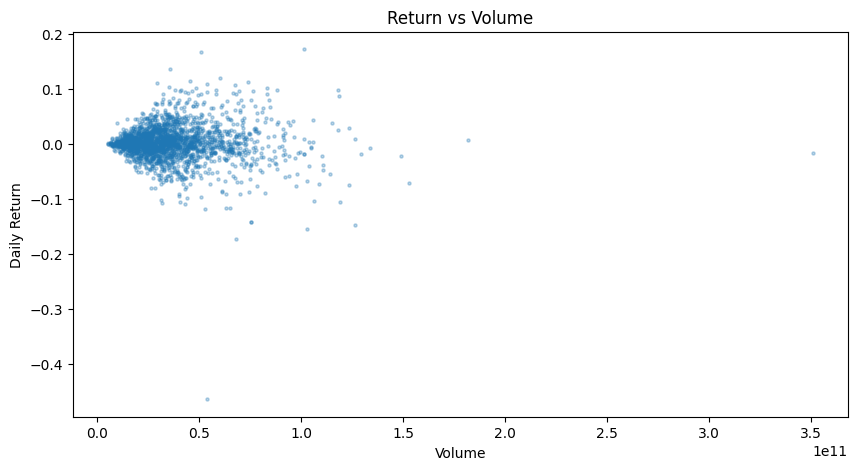

In [11]:
# Scatter plot — BTC return vs volume
plt.figure(figsize=(10, 5))
plt.scatter(btc["Volume"], btc["log_returns"], alpha=0.3, s=5)
plt.title("Return vs Volume")
plt.xlabel("Volume")
plt.ylabel("Daily Return")
plt.show()

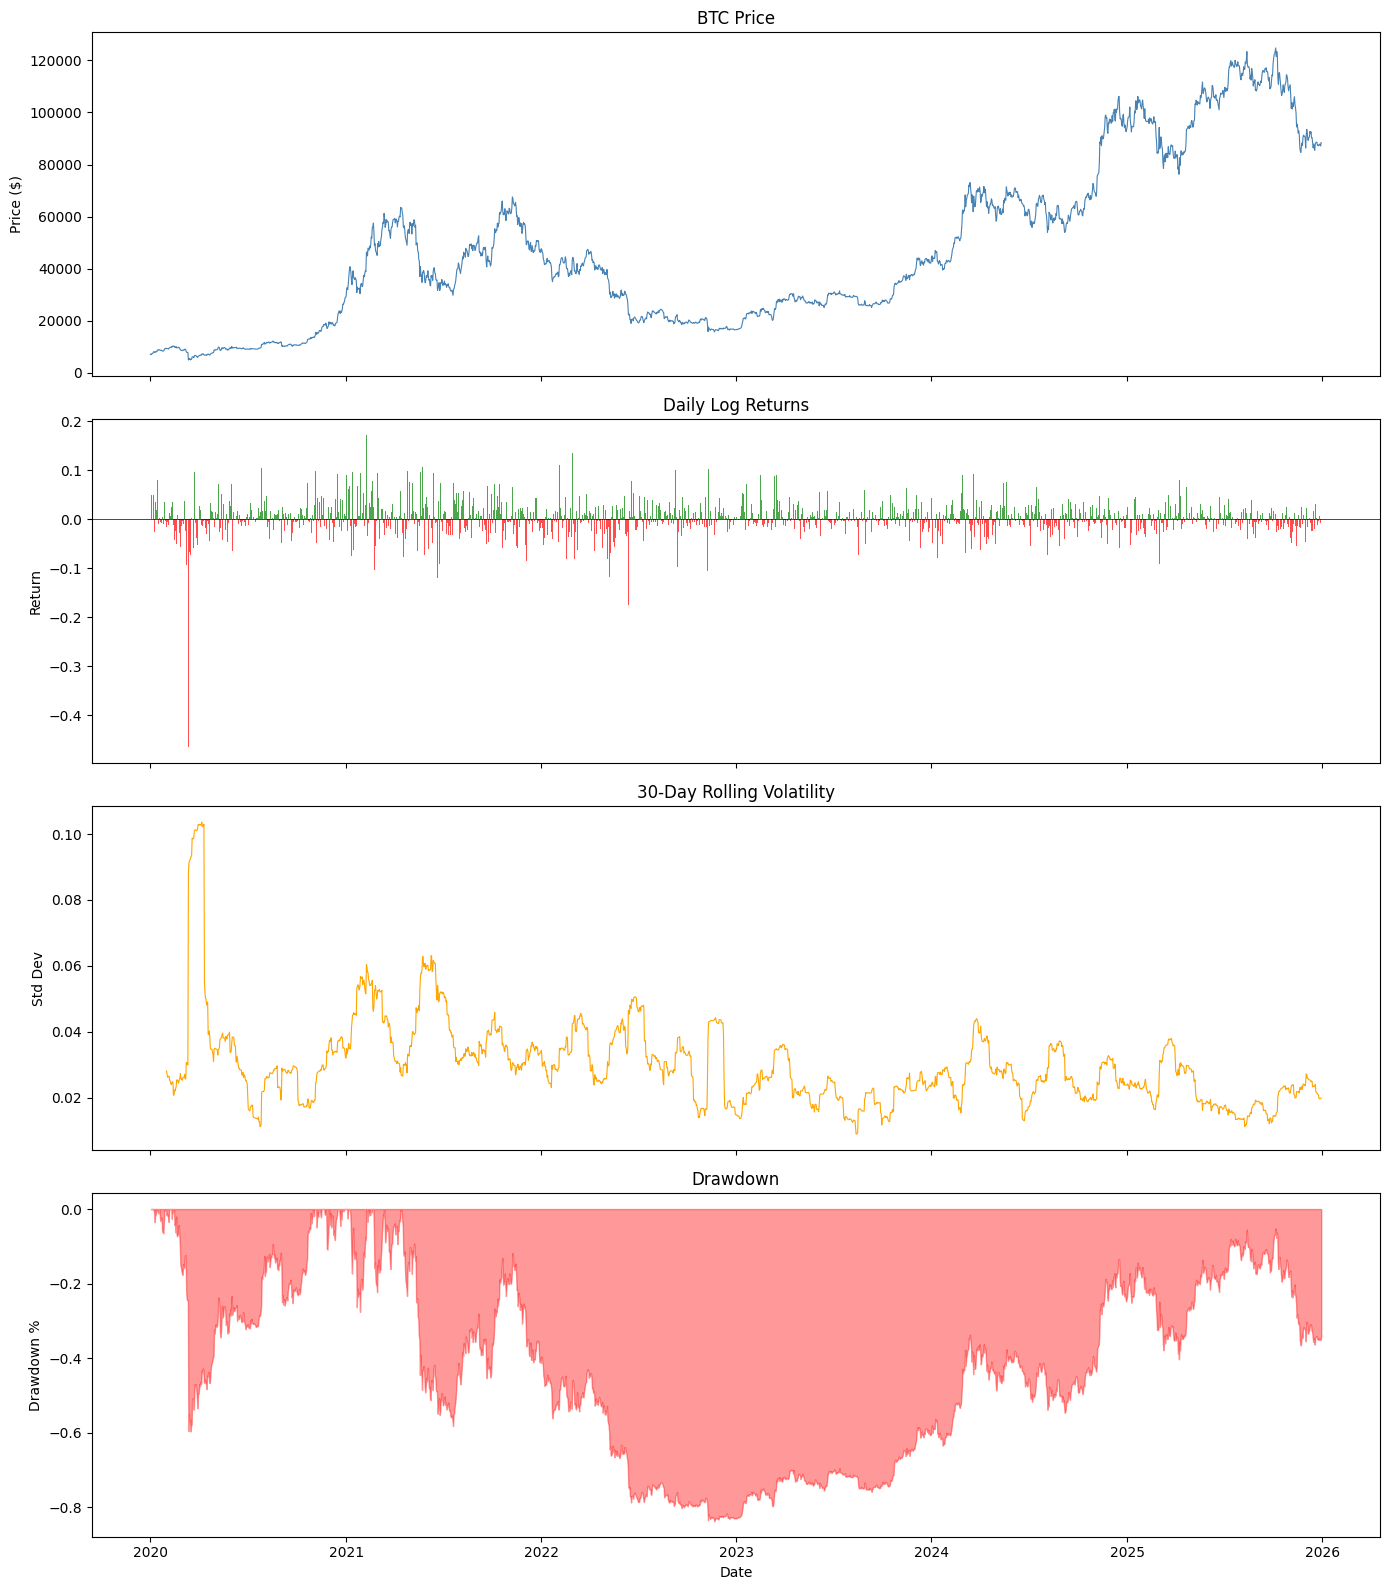

In [18]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
axes[0].plot(btc["Close"], color="steelblue", linewidth=0.8)
axes[0].set_title("BTC Price", fontsize=12)
axes[0].set_ylabel("Price ($)")

axes[1].bar(btc.index, btc["log_returns"], color=np.where(btc["log_returns"] > 0, "green", "red"), width=1, alpha=0.7)
axes[1].set_title("Daily Log Returns", fontsize=12)
axes[1].set_ylabel("Return")
axes[1].axhline(y=0, color="black", linewidth=0.5)

axes[2].plot(btc["rolling_vol_30"], color="orange", linewidth=0.8)
axes[2].set_title("30-Day Rolling Volatility", fontsize=12)
axes[2].set_ylabel("Std Dev")

# Calculate drawdown
cumulative = (1 + btc["log_returns"]).cumprod()
rolling_peak = cumulative.cummax()
drawdown = (cumulative - rolling_peak) / rolling_peak

axes[3].fill_between(btc.index, drawdown, 0, color="red", alpha=0.4)
axes[3].set_title("Drawdown", fontsize=12)
axes[3].set_ylabel("Drawdown %")
axes[3].set_xlabel("Date")

plt.tight_layout()
plt.show()

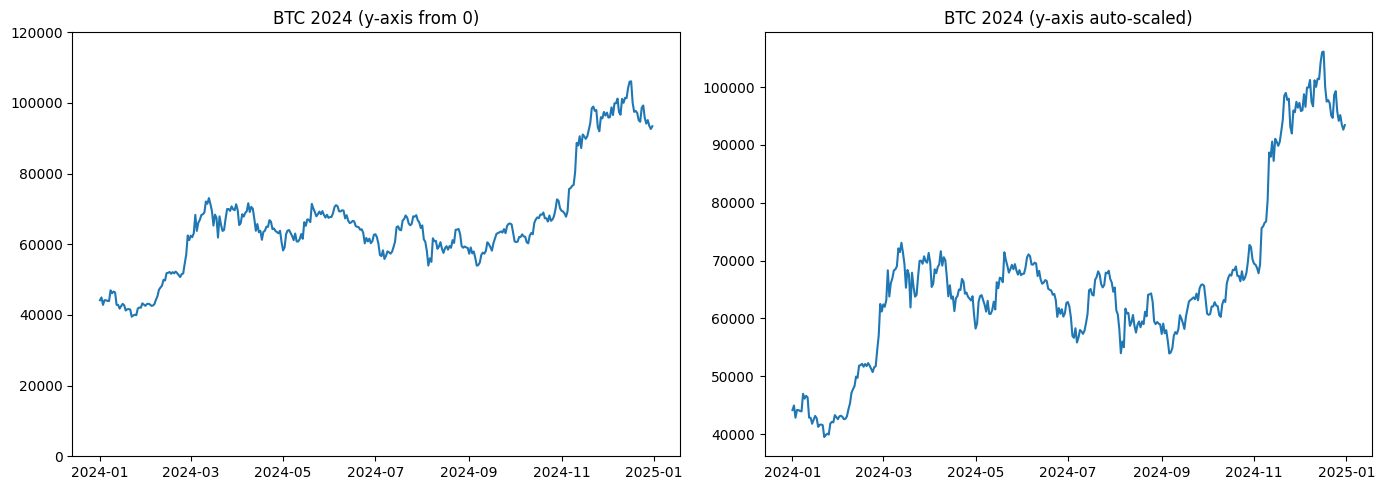

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart A — y-axis starts at 0
axes[0].plot(btc["Close"]["2024"])
axes[0].set_ylim(0, 120000)
axes[0].set_title("BTC 2024 (y-axis from 0)")

# Chart B — y-axis zoomed in
axes[1].plot(btc["Close"]["2024"])
axes[1].set_title("BTC 2024 (y-axis auto-scaled)")

plt.tight_layout()
plt.show()

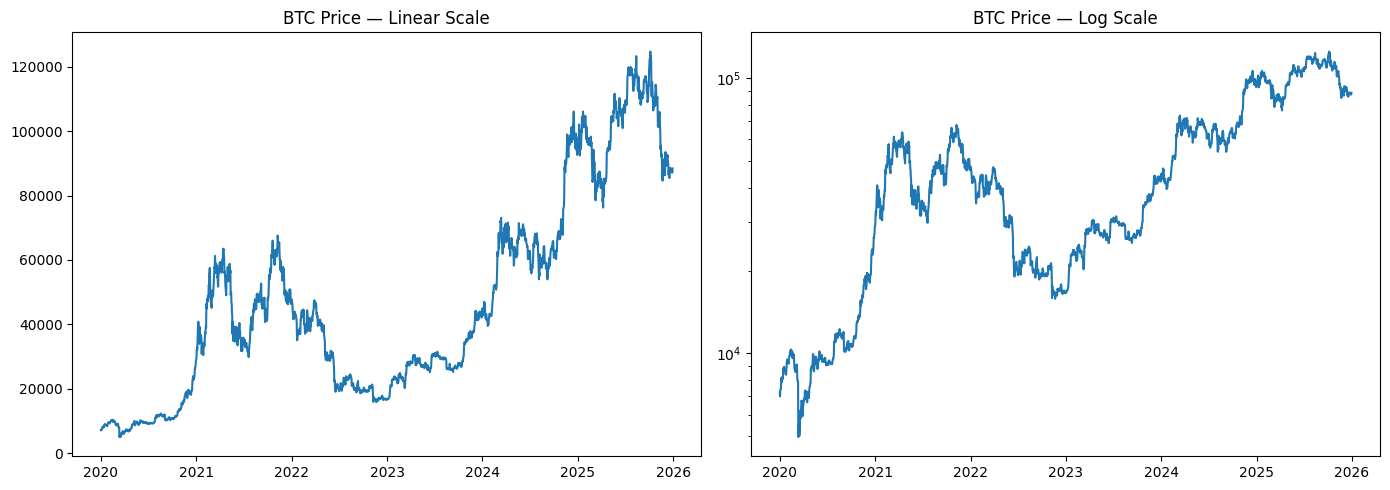

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(btc["Close"])
axes[0].set_title("BTC Price — Linear Scale")

axes[1].plot(btc["Close"])
axes[1].set_yscale("log")
axes[1].set_title("BTC Price — Log Scale")

plt.tight_layout()
plt.show()

1. What dates were chosen and why?
2. Is the y-axis manipulated?
3. How many things were tested before showing me this one winner?

Use linear when absolute change matters; use log when percentage change matters.